# Wikidata Prominent Anthropologists

Created by [Matt Artz](https://www.mattartz.me/) | [GitHub](https://github.com/MattArtzAnthro) | [ORCID](https://orcid.org/0000-0002-3822-1429)

---

## What This Notebook Does

Ranks ~13,000 Wikidata anthropologists by composite prominence using five metrics: Wikipedia sitelinks, doctoral students, incoming Wikidata links, awards, and authored scholarly works. Includes a "primary anthropologist" filter to exclude interdisciplinary scholars primarily known for other fields.

**Endpoint note**: Person data comes from the main Wikidata endpoint. Authored works are queried from the scholarly endpoint (`query-scholarly.wikidata.org`).

## Prominence Metrics

| Metric | Description | Weight |
|--------|-------------|--------|
| Sitelinks | Wikipedia articles about the person across languages | 0.25 |
| Doctoral Students | Academic lineage via P185 | 0.25 |
| Incoming Links | Other Wikidata items referencing this person | 0.20 |
| Awards | Honors and recognitions (P166) | 0.15 |
| Authored Works | Scholarly articles linked via P50 (scholarly endpoint) | 0.15 |

## Workflow

1. **Discover**: Query all anthropologists from Wikidata
2. **Compute metrics**: Batched queries for each prominence signal (~15-30 min)
3. **Score**: Log-normalized, weighted composite ranking
4. **Filter**: Optional "primary anthropologist" filter
5. **Visualize**: Distribution charts for each metric
6. **Export**: Timestamped CSVs (all + primary-only)

## Citation

If you use this notebook, please cite:

> Artz, M. (2026). Wikidata Prominent Anthropologists. GitHub. https://github.com/MattArtzAnthro/wikidata-tools

*A citable DOI will be available via Zenodo.*

## License

[CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/)

## Setup

In [1]:
# Install required packages
!pip install requests pandas matplotlib ipywidgets -q

import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import re
from datetime import datetime
from typing import Dict, List, Set, Optional, Tuple
from collections import defaultdict
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

print("✓ Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.3 MB/s eta 0:00:00
✓ Setup complete.


## Configuration

**Important**: Since May 2025, Wikidata underwent a graph split. Scholarly articles are now **only** available on the scholarly endpoint, while person data remains on the main endpoint.

In [2]:
class Config:
    # Wikidata endpoints
    WIKIDATA_ENDPOINT = "https://query.wikidata.org/sparql"
    SCHOLARLY_ENDPOINT = "https://query-scholarly.wikidata.org/sparql"

    # API settings
    USER_AGENT = "WikidataProminentAnthropologists/1.0 (https://www.mattartz.me/)"
    TIMEOUT = 90
    REQUEST_DELAY = 1.5  # Seconds between queries
    BATCH_SIZE = 200     # QIDs per query batch
    MAX_RETRIES = 3

    # Prominence metric weights (must sum to 1.0)
    WEIGHTS = {
        'sitelinks': 0.25,
        'doctoral_students': 0.25,
        'incoming_links': 0.20,
        'awards': 0.15,
        'authored_works': 0.15,
    }

    # Key Wikidata identifiers
    ANTHROPOLOGIST_QID = "Q4773904"  # occupation: anthropologist
    HUMAN_QID = "Q5"                  # instance of: human

    # Fields to potentially filter out (people primarily known for other work)
    COMPETING_OCCUPATIONS = {
        'Q4964182': 'philosopher',
        'Q36180': 'writer',
        'Q82955': 'politician',
        'Q37226': 'teacher',
        'Q1622272': 'university teacher',
        'Q901': 'scientist',
        'Q15980158': 'non-fiction writer',
    }

config = Config()

# Validate weights sum to 1.0
weight_sum = sum(config.WEIGHTS.values())
assert abs(weight_sum - 1.0) < 0.001, f"Weights must sum to 1.0, got {weight_sum}"

print(f"✓ Configuration loaded")
print(f"  Main endpoint: {config.WIKIDATA_ENDPOINT}")
print(f"  Scholarly endpoint: {config.SCHOLARLY_ENDPOINT}")
print(f"  Batch size: {config.BATCH_SIZE} QIDs per query")

✓ Configuration loaded
  Main endpoint: https://query.wikidata.org/sparql
  Scholarly endpoint: https://query-scholarly.wikidata.org/sparql
  Batch size: 200 QIDs per query


## SPARQL Query Functions

In [3]:
def run_sparql_query(query: str, endpoint: str = None, retries: int = None) -> Optional[pd.DataFrame]:
    """
    Execute a SPARQL query against Wikidata and return results as DataFrame.

    Args:
        query: SPARQL query string
        endpoint: SPARQL endpoint URL (defaults to main Wikidata)
        retries: Number of retry attempts

    Returns:
        DataFrame with query results, or None if query fails
    """
    if endpoint is None:
        endpoint = config.WIKIDATA_ENDPOINT
    if retries is None:
        retries = config.MAX_RETRIES

    headers = {
        'User-Agent': config.USER_AGENT,
        'Accept': 'application/sparql-results+json'
    }

    for attempt in range(retries):
        try:
            response = requests.get(
                endpoint,
                params={'query': query, 'format': 'json'},
                headers=headers,
                timeout=config.TIMEOUT
            )
            response.raise_for_status()

            data = response.json()
            bindings = data.get('results', {}).get('bindings', [])

            if not bindings:
                return pd.DataFrame()

            # Convert to DataFrame
            rows = []
            for binding in bindings:
                row = {}
                for key, value in binding.items():
                    row[key] = value.get('value', '')
                rows.append(row)

            return pd.DataFrame(rows)

        except requests.exceptions.Timeout:
            print(f"  ⚠ Query timeout (attempt {attempt + 1}/{retries})")
            if attempt < retries - 1:
                time.sleep(config.REQUEST_DELAY * 2)
        except requests.exceptions.RequestException as e:
            print(f"  ⚠ Request error: {e} (attempt {attempt + 1}/{retries})")
            if attempt < retries - 1:
                time.sleep(config.REQUEST_DELAY * 2)

    return None


def extract_qid(uri: str) -> str:
    """Extract QID from Wikidata URI."""
    if not uri:
        return ''
    match = re.search(r'Q\d+', uri)
    return match.group(0) if match else ''


print("✓ Query functions defined")

✓ Query functions defined


## Phase 1: Discover All Anthropologists

First, we retrieve all Wikidata items with occupation (P106) = anthropologist (Q4773904).

In [4]:
def discover_anthropologists() -> pd.DataFrame:
    """
    Query Wikidata for all people with occupation anthropologist.
    Returns DataFrame with QID, label, and all occupations.
    """
    print("Discovering anthropologists in Wikidata...")

    query = """
    SELECT ?person ?personLabel
           (GROUP_CONCAT(DISTINCT ?occupationLabel; separator="; ") AS ?occupations)
           (GROUP_CONCAT(DISTINCT ?occupation; separator="; ") AS ?occupationQIDs)
    WHERE {
      ?person wdt:P106 wd:Q4773904 .  # occupation: anthropologist
      ?person wdt:P31 wd:Q5 .          # instance of: human

      # Get all occupations for filtering
      ?person wdt:P106 ?occupation .
      ?occupation rdfs:label ?occupationLabel .
      FILTER(LANG(?occupationLabel) = "en")

      SERVICE wikibase:label { bd:serviceParam wikibase:language "en". }
    }
    GROUP BY ?person ?personLabel
    """

    df = run_sparql_query(query)

    if df is None or df.empty:
        print("⚠ Failed to retrieve anthropologists")
        return pd.DataFrame()

    # Extract QIDs from URIs
    df['qid'] = df['person'].apply(extract_qid)

    print(f"✓ Found {len(df):,} anthropologists")
    return df


# Run discovery
anthropologists_df = discover_anthropologists()

if not anthropologists_df.empty:
    print(f"\nSample of discovered anthropologists:")
    display(anthropologists_df[['qid', 'personLabel', 'occupations']].head(10))

Discovering anthropologists in Wikidata...
✓ Found 12,733 anthropologists

Sample of discovered anthropologists:


,qid,personLabel,occupations
0,Q6701,Jacob Grimm,writer; politician; jurist; librarian; histori...
1,Q6714,Wilhelm Grimm,writer; jurist; librarian; pedagogue; universi...
2,Q9049,Noam Chomsky,writer; computer scientist; psychologist; hist...
3,Q9294,Ibn Khaldun,writer; judge; poet; politician; economist; hi...
4,Q9312,Immanuel Kant,writer; physicist; mathematician; librarian; p...
5,Q11826,Al-Biruni,writer; astronomer; pharmacist; physicist; mat...
6,Q88429,Rudolf Pöch,photographer; physician; university teacher; e...
7,Q88737,Emanuel von Friedrichsthal,photographer; botanist; botanical collector; a...
8,Q89624,John Stanislaw Kubary,photographer; physician; ornithologist; illust...
9,Q88464,Ernst von Bibra,writer; engineer; chemist; botanist; entomolog...


## Phase 2: Compute Prominence Metrics

We compute each metric in batches to avoid query timeouts.

In [5]:
def batch_qids(qids: List[str], batch_size: int = None) -> List[List[str]]:
    """Split QID list into batches."""
    if batch_size is None:
        batch_size = config.BATCH_SIZE
    return [qids[i:i + batch_size] for i in range(0, len(qids), batch_size)]


def format_qids_for_values(qids: List[str]) -> str:
    """Format QID list for SPARQL VALUES clause."""
    return ' '.join([f'wd:{qid}' for qid in qids])


print("✓ Batch utilities defined")

✓ Batch utilities defined


### Metric 1: Wikipedia Sitelinks

Count how many Wikipedia language editions have articles about each person.

In [6]:
def get_sitelinks_batch(qids: List[str]) -> Dict[str, int]:
    """Get sitelink counts for a batch of QIDs."""
    qid_values = format_qids_for_values(qids)

    query = f"""
    SELECT ?person (COUNT(DISTINCT ?sitelink) AS ?sitelinks) WHERE {{
      VALUES ?person {{ {qid_values} }}
      ?sitelink schema:about ?person .
    }}
    GROUP BY ?person
    """

    df = run_sparql_query(query)

    if df is None or df.empty:
        return {}

    result = {}
    for _, row in df.iterrows():
        qid = extract_qid(row['person'])
        result[qid] = int(row['sitelinks'])

    return result


def compute_all_sitelinks(qids: List[str], progress_widget=None) -> Dict[str, int]:
    """Compute sitelinks for all QIDs in batches."""
    batches = batch_qids(qids)
    all_results = {}

    for i, batch in enumerate(batches):
        if progress_widget:
            progress_widget.value = int((i + 1) / len(batches) * 100)

        results = get_sitelinks_batch(batch)
        all_results.update(results)

        if i < len(batches) - 1:
            time.sleep(config.REQUEST_DELAY)

    return all_results


print("✓ Sitelinks metric defined")

✓ Sitelinks metric defined


### Metric 2: Doctoral Students

Count doctoral students (P185) for each anthropologist.

In [7]:
def get_doctoral_students_batch(qids: List[str]) -> Dict[str, int]:
    """Get doctoral student counts for a batch of QIDs."""
    qid_values = format_qids_for_values(qids)

    query = f"""
    SELECT ?person (COUNT(DISTINCT ?student) AS ?students) WHERE {{
      VALUES ?person {{ {qid_values} }}
      ?person wdt:P185 ?student .
    }}
    GROUP BY ?person
    """

    df = run_sparql_query(query)

    if df is None or df.empty:
        return {}

    result = {}
    for _, row in df.iterrows():
        qid = extract_qid(row['person'])
        result[qid] = int(row['students'])

    return result


def compute_all_doctoral_students(qids: List[str], progress_widget=None) -> Dict[str, int]:
    """Compute doctoral students for all QIDs in batches."""
    batches = batch_qids(qids)
    all_results = {}

    for i, batch in enumerate(batches):
        if progress_widget:
            progress_widget.value = int((i + 1) / len(batches) * 100)

        results = get_doctoral_students_batch(batch)
        all_results.update(results)

        if i < len(batches) - 1:
            time.sleep(config.REQUEST_DELAY)

    return all_results


print("✓ Doctoral students metric defined")

✓ Doctoral students metric defined


### Metric 3: Awards and Honors

Count awards (P166) for each anthropologist.

In [8]:
def get_awards_batch(qids: List[str]) -> Dict[str, int]:
    """Get award counts for a batch of QIDs."""
    qid_values = format_qids_for_values(qids)

    query = f"""
    SELECT ?person (COUNT(DISTINCT ?award) AS ?awards) WHERE {{
      VALUES ?person {{ {qid_values} }}
      ?person wdt:P166 ?award .
    }}
    GROUP BY ?person
    """

    df = run_sparql_query(query)

    if df is None or df.empty:
        return {}

    result = {}
    for _, row in df.iterrows():
        qid = extract_qid(row['person'])
        result[qid] = int(row['awards'])

    return result


def compute_all_awards(qids: List[str], progress_widget=None) -> Dict[str, int]:
    """Compute awards for all QIDs in batches."""
    batches = batch_qids(qids)
    all_results = {}

    for i, batch in enumerate(batches):
        if progress_widget:
            progress_widget.value = int((i + 1) / len(batches) * 100)

        results = get_awards_batch(batch)
        all_results.update(results)

        if i < len(batches) - 1:
            time.sleep(config.REQUEST_DELAY)

    return all_results


print("✓ Awards metric defined")

✓ Awards metric defined


### Metric 4: Incoming Links (Backlinks)

Count how many other Wikidata items reference each person.

In [9]:
def get_incoming_links_batch(qids: List[str]) -> Dict[str, int]:
    """Get incoming link counts for a batch of QIDs."""
    qid_values = format_qids_for_values(qids)

    # Exclude sitelinks (schema:about) and focus on statement references
    query = f"""
    SELECT ?person (COUNT(DISTINCT ?referencing) AS ?inlinks) WHERE {{
      VALUES ?person {{ {qid_values} }}
      ?referencing ?prop ?person .
      FILTER(?prop != schema:about)
      FILTER(STRSTARTS(STR(?referencing), "http://www.wikidata.org/entity/Q"))
    }}
    GROUP BY ?person
    """

    df = run_sparql_query(query)

    if df is None or df.empty:
        return {}

    result = {}
    for _, row in df.iterrows():
        qid = extract_qid(row['person'])
        result[qid] = int(row['inlinks'])

    return result


def compute_all_incoming_links(qids: List[str], progress_widget=None) -> Dict[str, int]:
    """Compute incoming links for all QIDs in batches."""
    # Use smaller batches for this more expensive query
    batches = batch_qids(qids, batch_size=100)
    all_results = {}

    for i, batch in enumerate(batches):
        if progress_widget:
            progress_widget.value = int((i + 1) / len(batches) * 100)

        results = get_incoming_links_batch(batch)
        all_results.update(results)

        if i < len(batches) - 1:
            time.sleep(config.REQUEST_DELAY * 1.5)  # Extra delay for heavy query

    return all_results


print("✓ Incoming links metric defined")

✓ Incoming links metric defined


### Metric 5: Authored Scholarly Works

Count scholarly articles where the person is listed as author (P50). This uses the scholarly endpoint.

In [10]:
def get_authored_works_batch(qids: List[str]) -> Dict[str, int]:
    """Get authored work counts from scholarly endpoint."""
    qid_values = format_qids_for_values(qids)

    query = f"""
    SELECT ?person (COUNT(DISTINCT ?work) AS ?works) WHERE {{
      VALUES ?person {{ {qid_values} }}
      ?work wdt:P50 ?person .
    }}
    GROUP BY ?person
    """

    # Use scholarly endpoint for this query
    df = run_sparql_query(query, endpoint=config.SCHOLARLY_ENDPOINT)

    if df is None or df.empty:
        return {}

    result = {}
    for _, row in df.iterrows():
        qid = extract_qid(row['person'])
        result[qid] = int(row['works'])

    return result


def compute_all_authored_works(qids: List[str], progress_widget=None) -> Dict[str, int]:
    """Compute authored works for all QIDs in batches."""
    batches = batch_qids(qids, batch_size=150)
    all_results = {}

    for i, batch in enumerate(batches):
        if progress_widget:
            progress_widget.value = int((i + 1) / len(batches) * 100)

        results = get_authored_works_batch(batch)
        all_results.update(results)

        if i < len(batches) - 1:
            time.sleep(config.REQUEST_DELAY)

    return all_results


print("✓ Authored works metric defined")

✓ Authored works metric defined


## Phase 3: Run All Metrics

Execute all prominence calculations with progress tracking.

In [11]:
# Create progress widgets
overall_progress = widgets.IntProgress(
    value=0, min=0, max=100,
    description='Overall:',
    style={'bar_color': '#3498db'}
)
metric_progress = widgets.IntProgress(
    value=0, min=0, max=100,
    description='Current:',
    style={'bar_color': '#2ecc71'}
)
status_label = widgets.Label(value='Ready to compute metrics')

run_button = widgets.Button(
    description='Compute All Metrics',
    button_style='primary',
    icon='play'
)
output = widgets.Output()

# Storage for results
metrics_results = {}

def run_all_metrics(button):
    global metrics_results

    with output:
        clear_output()

        if anthropologists_df.empty:
            print("⚠ No anthropologists loaded. Run discovery first.")
            return

        qids = anthropologists_df['qid'].tolist()
        print(f"Computing metrics for {len(qids):,} anthropologists...\n")

        metrics = [
            ('sitelinks', 'Wikipedia Sitelinks', compute_all_sitelinks),
            ('doctoral_students', 'Doctoral Students', compute_all_doctoral_students),
            ('awards', 'Awards & Honors', compute_all_awards),
            ('incoming_links', 'Incoming Links', compute_all_incoming_links),
            ('authored_works', 'Authored Works (Scholarly)', compute_all_authored_works),
        ]

        for i, (key, name, func) in enumerate(metrics):
            overall_progress.value = int((i / len(metrics)) * 100)
            metric_progress.value = 0
            status_label.value = f'Computing: {name}...'

            print(f"📊 {name}...")
            start_time = time.time()

            results = func(qids, progress_widget=metric_progress)
            metrics_results[key] = results

            elapsed = time.time() - start_time
            non_zero = sum(1 for v in results.values() if v > 0)
            print(f"   ✓ Complete: {non_zero:,} with values ({elapsed:.1f}s)\n")

        overall_progress.value = 100
        metric_progress.value = 100
        status_label.value = '✓ All metrics computed!'

        print("="*50)
        print("✓ All metrics computed successfully!")
        print("\nProceed to Phase 4 to calculate composite scores.")

run_button.on_click(run_all_metrics)

display(widgets.VBox([
    widgets.HTML("<h4>Compute Prominence Metrics</h4>"),
    widgets.HTML(f"<p>This will query Wikidata for {len(anthropologists_df):,} anthropologists.</p>"),
    run_button,
    overall_progress,
    metric_progress,
    status_label,
    output
]))

## Phase 4: Calculate Composite Scores

Combine all metrics into a weighted composite prominence score.

In [12]:
def normalize_metric(values: Dict[str, int]) -> Dict[str, float]:
    """
    Normalize metric values to 0-1 range using min-max scaling.
    Uses log transformation for highly skewed distributions.
    """
    import math

    if not values:
        return {}

    # Apply log(1+x) to handle skewed distributions
    log_values = {k: math.log1p(v) for k, v in values.items()}

    max_val = max(log_values.values()) if log_values else 1
    if max_val == 0:
        return {k: 0.0 for k in values}

    return {k: v / max_val for k, v in log_values.items()}


def calculate_composite_scores(df: pd.DataFrame, metrics: Dict[str, Dict[str, int]]) -> pd.DataFrame:
    """
    Calculate weighted composite prominence scores.
    """
    result_df = df.copy()

    # Add raw metric columns
    for metric_name, values in metrics.items():
        result_df[metric_name] = result_df['qid'].map(lambda x: values.get(x, 0))

    # Normalize each metric
    normalized = {}
    for metric_name, values in metrics.items():
        normalized[metric_name] = normalize_metric(values)
        result_df[f'{metric_name}_norm'] = result_df['qid'].map(
            lambda x: normalized[metric_name].get(x, 0.0)
        )

    # Calculate weighted composite score
    result_df['composite_score'] = 0.0
    for metric_name, weight in config.WEIGHTS.items():
        if metric_name in normalized:
            result_df['composite_score'] += result_df[f'{metric_name}_norm'] * weight

    # Sort by composite score
    result_df = result_df.sort_values('composite_score', ascending=False).reset_index(drop=True)
    result_df['rank'] = result_df.index + 1

    return result_df


print("✓ Scoring functions defined")

✓ Scoring functions defined


In [13]:
# Calculate composite scores
if metrics_results:
    print("Calculating composite prominence scores...\n")

    prominence_df = calculate_composite_scores(anthropologists_df, metrics_results)

    print("✓ Composite scores calculated!\n")
    print(f"Metric weights applied: {config.WEIGHTS}\n")

    # Show top results
    display_cols = ['rank', 'qid', 'personLabel', 'sitelinks', 'doctoral_students',
                    'awards', 'incoming_links', 'authored_works', 'composite_score']

    print("🏆 Top 25 Most Prominent Anthropologists:")
    display(prominence_df[display_cols].head(25))
else:
    print("⚠ No metrics computed yet. Run Phase 3 first.")

Calculating composite prominence scores...

✓ Composite scores calculated!

Metric weights applied: {'sitelinks': 0.25, 'doctoral_students': 0.25, 'incoming_links': 0.2, 'awards': 0.15, 'authored_works': 0.15}

🏆 Top 25 Most Prominent Anthropologists:


,rank,qid,personLabel,sitelinks,doctoral_students,awards,incoming_links,authored_works,composite_score
0,1,Q9049,Noam Chomsky,185,21,42,233,47,0.846452
1,2,Q212730,Steven Pinker,61,9,13,54,59,0.662652
2,3,Q381678,André Leroi-Gourhan,25,24,3,48,15,0.614436
3,4,Q128126,Claude Lévi-Strauss,99,5,23,92,2,0.606320
4,5,Q76857,Franz Boas,67,22,0,68,11,0.603076
5,6,Q78477,Joseph Schumpeter,71,10,1,54,17,0.577388
6,7,Q355237,Bruno Latour,50,3,17,57,22,0.570280
7,8,Q335189,Colin Renfrew,36,3,5,51,121,0.552796
8,9,Q180099,Margaret Mead,93,2,9,40,22,0.545311
9,10,Q657995,Georges Balandier,17,21,7,45,0,0.545298


## Phase 5: Filter for "Primary" Anthropologists

Many people listed as anthropologists are primarily known for other fields (philosophy, linguistics, politics). This section allows filtering to focus on scholars whose primary identity is anthropology.

In [14]:
def is_primarily_anthropologist(row: pd.Series) -> bool:
    """
    Heuristic to identify if anthropology is the person's primary field.
    Returns True if anthropology-related terms dominate their occupations.
    """
    occupations = str(row.get('occupations', '')).lower()
    occupation_qids = str(row.get('occupationQIDs', ''))

    # Check for competing high-profile occupations
    competing_count = 0
    for qid, name in config.COMPETING_OCCUPATIONS.items():
        if qid in occupation_qids:
            competing_count += 1

    # Count anthropology-related occupations
    anthro_terms = ['anthropolog', 'ethnograph', 'ethnolog', 'archaeolog']
    anthro_count = sum(1 for term in anthro_terms if term in occupations)

    # Consider primarily anthropologist if anthro occupations >= competing occupations
    return anthro_count >= competing_count


if 'prominence_df' in dir() and not prominence_df.empty:
    # Apply filter
    prominence_df['is_primary_anthropologist'] = prominence_df.apply(is_primarily_anthropologist, axis=1)

    primary_df = prominence_df[prominence_df['is_primary_anthropologist']].copy()
    primary_df['primary_rank'] = range(1, len(primary_df) + 1)

    print(f"\n📊 Filtering Results:")
    print(f"   Total anthropologists: {len(prominence_df):,}")
    print(f"   Primary anthropologists: {len(primary_df):,}")
    print(f"   Filtered out: {len(prominence_df) - len(primary_df):,}")

    print("\n🏆 Top 25 Primary Anthropologists:")
    display_cols = ['primary_rank', 'qid', 'personLabel', 'sitelinks', 'doctoral_students',
                    'awards', 'incoming_links', 'authored_works', 'composite_score']
    display(primary_df[display_cols].head(25))
else:
    print("⚠ Run Phase 4 first to calculate scores.")


📊 Filtering Results:
   Total anthropologists: 12,733
   Primary anthropologists: 12,219
   Filtered out: 514

🏆 Top 25 Primary Anthropologists:


,primary_rank,qid,personLabel,sitelinks,doctoral_students,awards,incoming_links,authored_works,composite_score
2,1,Q381678,André Leroi-Gourhan,25,24,3,48,15,0.614436
7,2,Q335189,Colin Renfrew,36,3,5,51,121,0.552796
8,3,Q180099,Margaret Mead,93,2,9,40,22,0.545311
9,4,Q657995,Georges Balandier,17,21,7,45,0,0.545298
14,5,Q556140,Ian Hodder,23,3,6,29,81,0.515133
15,6,Q1382212,Yves Coppens,21,4,20,25,9,0.514581
17,7,Q179047,Charles Higham,10,6,6,21,32,0.493564
18,8,Q706078,Marc Augé,26,11,7,17,0,0.492372
19,9,Q621113,Alexey Okladnikov,17,5,10,30,6,0.492186
22,10,Q164566,Barry Cunliffe,18,1,9,94,63,0.487513


## Phase 6: Visualization

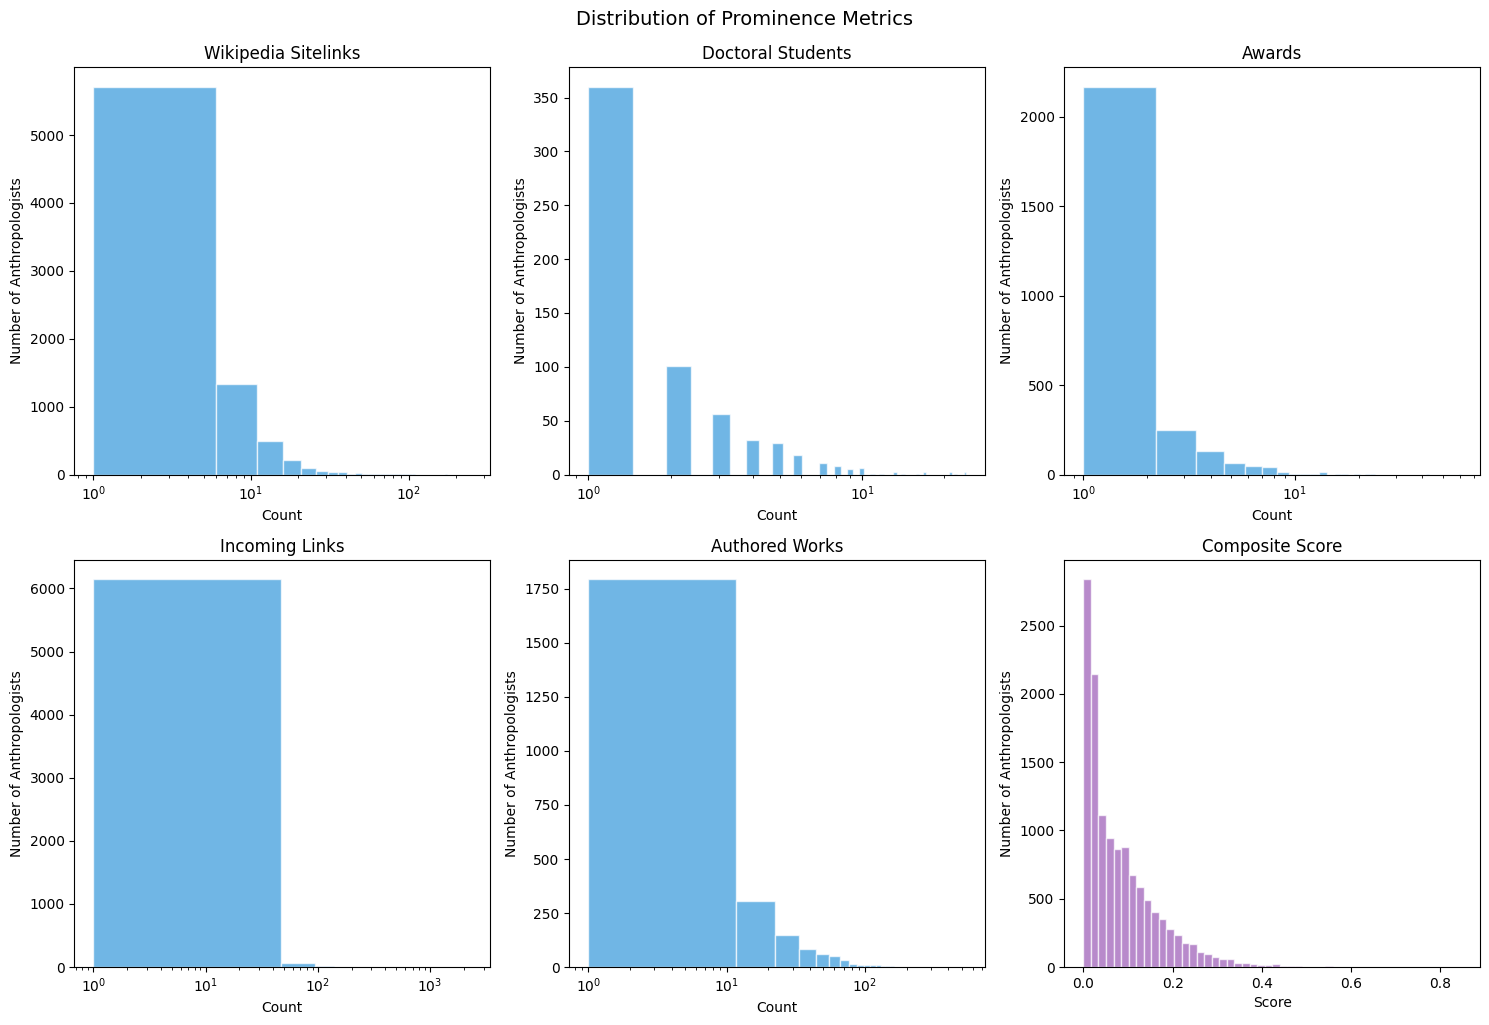


📊 Summary Statistics:
       sitelinks  doctoral_students    awards  incoming_links  authored_works
count   12733.00           12733.00  12733.00        12733.00        12733.00
mean        3.67               0.12      0.44            3.28            2.91
std         8.46               0.85      1.39           28.57           14.45
min         0.00               0.00      0.00            0.00            0.00
25%         0.00               0.00      0.00            0.00            0.00
50%         1.00               0.00      0.00            0.00            0.00
75%         4.00               0.00      0.00            2.00            0.00
max       249.00              24.00     61.00         2325.00          538.00


In [15]:
if 'prominence_df' in dir() and not prominence_df.empty:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    metrics_to_plot = [
        ('sitelinks', 'Wikipedia Sitelinks'),
        ('doctoral_students', 'Doctoral Students'),
        ('awards', 'Awards'),
        ('incoming_links', 'Incoming Links'),
        ('authored_works', 'Authored Works'),
        ('composite_score', 'Composite Score'),
    ]

    for ax, (col, title) in zip(axes.flatten(), metrics_to_plot):
        data = prominence_df[col].dropna()
        if col == 'composite_score':
            ax.hist(data, bins=50, color='#9b59b6', edgecolor='white', alpha=0.7)
        else:
            # Log scale for raw counts
            data_nonzero = data[data > 0]
            if len(data_nonzero) > 0:
                ax.hist(data_nonzero, bins=50, color='#3498db', edgecolor='white', alpha=0.7)
                ax.set_xscale('log')
        ax.set_title(title)
        ax.set_xlabel('Count' if col != 'composite_score' else 'Score')
        ax.set_ylabel('Number of Anthropologists')

    plt.tight_layout()
    plt.suptitle('Distribution of Prominence Metrics', y=1.02, fontsize=14)
    plt.show()

    # Summary statistics
    print("\n📊 Summary Statistics:")
    summary_cols = ['sitelinks', 'doctoral_students', 'awards', 'incoming_links', 'authored_works']
    print(prominence_df[summary_cols].describe().round(2))
else:
    print("⚠ Run previous phases first.")

## Phase 7: Export Results

In [16]:
export_button = widgets.Button(
    description='Export to CSV',
    button_style='success',
    icon='download'
)
export_output = widgets.Output()

def export_results(button):
    with export_output:
        clear_output()

        if 'prominence_df' not in dir() or prominence_df.empty:
            print("⚠ No results to export. Run previous phases first.")
            return

        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

        # Export all anthropologists
        all_filename = f"wikidata_prominent_anthropologists_all_{timestamp}.csv"
        export_cols = ['rank', 'qid', 'personLabel', 'occupations',
                       'sitelinks', 'doctoral_students', 'awards',
                       'incoming_links', 'authored_works', 'composite_score',
                       'is_primary_anthropologist']
        prominence_df[export_cols].to_csv(all_filename, index=False)
        print(f"✓ Exported all results: {all_filename}")

        # Export primary anthropologists only
        if 'primary_df' in dir() and not primary_df.empty:
            primary_filename = f"wikidata_prominent_anthropologists_primary_{timestamp}.csv"
            primary_export_cols = ['primary_rank', 'qid', 'personLabel', 'occupations',
                                   'sitelinks', 'doctoral_students', 'awards',
                                   'incoming_links', 'authored_works', 'composite_score']
            primary_df[primary_export_cols].to_csv(primary_filename, index=False)
            print(f"✓ Exported primary anthropologists: {primary_filename}")

        # Download files (Colab)
        try:
            from google.colab import files
            files.download(all_filename)
            if 'primary_df' in dir() and not primary_df.empty:
                files.download(primary_filename)
        except ImportError:
            print("\n(Not in Colab - files saved to working directory)")

export_button.on_click(export_results)
display(widgets.VBox([export_button, export_output]))

---

## Notes

- Person data comes from the **main Wikidata endpoint**; authored works come from the **scholarly endpoint** (`query-scholarly.wikidata.org`).
- Processing ~13,000 anthropologists takes approximately 15-30 minutes depending on query response times.
- The composite score uses log-normalization to handle highly skewed distributions (a few people have hundreds of sitelinks while most have fewer than 10).
- The "primary anthropologist" filter is heuristic and may incorrectly classify some interdisciplinary scholars.
- Citation data in Wikidata is sparse; consider supplementing with OpenAlex or Semantic Scholar for more complete bibliometric analysis.